# Speculative Decoding

In notebook 01 we saw the core problem: decoding runs at ~1 FLOP/byte, far below the A100 ridge point
of ~153 FLOP/byte, so the GPU idles. Batching fixes this *if* you have concurrent requests. Speculative
decoding fixes it **without** them.

**The idea (slide recap).** A small **drafter** proposes $\gamma$ tokens
$\hat{s}_{m+1}, \ldots, \hat{s}_{m+\gamma}$ autoregressively. The **verifier** (the model we actually
want to sample from) then scores all $\gamma$ proposals in a *single* forward pass. This is a
$(\gamma, d) \times (d, d)$ matmul instead of $\gamma$ separate $(1, d) \times (d, d)$ ones. We accept
the longest prefix where the verifier's top-1 token agrees with the proposal, and throw away everything
after the first rejection. The verifier's distribution is unchanged, so the speedup is **lossless**.

**The model to test (slide recap).**
$$
T_{\text{round}} = \gamma T_d + T_v, \qquad
\mathbb{E}[\text{tokens/round}] = \frac{1-\alpha^{\gamma+1}}{1-\alpha}, \qquad
\text{Speedup} = \frac{T_v}{\gamma T_d + T_v} \cdot \frac{1-\alpha^{\gamma+1}}{1-\alpha}
$$

#### Sonnet

In [6]:
sonnet = """FROM fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou, contracted to thine own bright eyes,
Feed'st thy light'st flame with self-substantial fuel,
Making a famine where abundance lies,
Thyself thy foe, to thy sweet self too cruel.
Thou that art now the world's fresh ornament
And only herald to the gaudy spring,
Within thine own bud buriest thy content
And, tender churl, makest waste in niggarding.
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.
When forty winters shall beseige thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery, so gazed on now,
Will be a tatter'd weed, of small worth held:
Then being ask'd where all thy beauty lies,
Where all the treasure of thy lusty days,
To say, within thine own deep-sunken eyes,
Were an all-eating shame and thriftless praise.
How much more praise deserved thy beauty's use,
If thou couldst answer 'This fair child of mine
Shall sum my count and make my old excuse,'
Proving his beauty by succession thine!
This were to be new made when thou art old,
And see thy blood warm when thou feel'st it cold.
Look in thy glass, and tell the face thou viewest
Now is the time that face should form another;
Whose fresh repair if now thou not renewest,
Thou dost beguile the world, unbless some mother.
For where is she so fair whose unear'd womb
Disdains the tillage of thy husbandry?
Or who is he so fond will be the tomb
Of his self-love, to stop posterity?
Thou art thy mother's glass, and she in thee
Calls back the lovely April of her prime:
So thou through windows of thine age shall see
Despite of wrinkles this thy golden time.
But if thou live, remember'd not to be,
Die single, and thine image dies with thee.
Unthrifty loveliness, why dost thou spend
Upon thyself thy beauty's legacy?
Nature's bequest gives nothing but doth lend,
And being frank she lends to those are free.
Then, beauteous niggard, why dost thou abuse
The bounteous largess given thee to give?
Profitless usurer, why dost thou use
So great a sum of sums, yet canst not live?
For having traffic with thyself alone,
Thou of thyself thy sweet self dost deceive.
Then how, when nature calls thee to be gone,
What acceptable audit canst thou leave?
Thy unused beauty must be tomb'd with thee,
Which, used, lives th' executor to be.
Those hours, that with gentle work did frame
The lovely gaze where every eye doth dwell,
Will play the tyrants to the very same
And that unfair which fairly doth excel:
For never-resting time leads summer on
To hideous winter and confounds him there;
Sap cheque'd with frost and lusty leaves quite gone,
Beauty o'ersnow'd and bareness every where:
Then, were not summer's distillation left,
A liquid prisoner pent in walls of glass,
Beauty's effect with beauty were bereft,
Nor it nor no remembrance what it was:
But flowers distill'd though they with winter meet,
Leese but their show; their substance still lives sweet.
Then let not winter's ragged hand deface
In thee thy summer, ere thou be distill'd:
Make sweet some vial; treasure thou some place
With beauty's treasure, ere it be self-kill'd.
That use is not forbidden usury,
Which happies those that pay the willing loan;
That's for thyself to breed another thee,
Or ten times happier, be it ten for one;
Ten times thyself were happier than thou art,
If ten of thine ten times refigured thee:
Then what could death do, if thou shouldst depart,
Leaving thee living in posterity?
Be not self-will'd, for thou art much too fair
To be death's conquest and make worms thine heir.
Lo! in the orient when the gracious light
Lifts up his burning head, each under eye
Doth homage to his new-appearing sight,
Serving with looks his sacred majesty;
And having climb'd the steep-up heavenly hill,
Resembling strong youth in his middle age,
yet mortal looks adore his beauty still,
Attending on his golden pilgrimage;
But when from highmost pitch, with weary car,
Like feeble age, he reeleth from the day,
The eyes, 'fore duteous, now converted are
From his low tract and look another way:
So thou, thyself out-going in thy noon,
Unlook'd on diest, unless thou get a son.
Music to hear, why hear'st thou music sadly?
Sweets with sweets war not, joy delights in joy.
Why lovest thou that which thou receivest not gladly,
Or else receivest with pleasure thine annoy?
If the true concord of well-tuned sounds,
By unions married, do offend thine ear,
They do but sweetly chide thee, who confounds
In singleness the parts that thou shouldst bear.
Mark how one string, sweet husband to another,
Strikes each in each by mutual ordering,
Resembling sire and child and happy mother
Who all in one, one pleasing note do sing:
Whose speechless song, being many, seeming one,
Sings this to thee: 'thou single wilt prove none.'
Is it for fear to wet a widow's eye
That thou consumest thyself in single life?
Ah! if thou issueless shalt hap to die.
The world will wail thee, like a makeless wife;
The world will be thy widow and still weep
That thou no form of thee hast left behind,
When every private widow well may keep
By children's eyes her husband's shape in mind.
Look, what an unthrift in the world doth spend
Shifts but his place, for still the world enjoys it;
But beauty's waste hath in the world an end,
And kept unused, the user so destroys it.
No love toward others in that bosom sits
That on himself such murderous shame commits.
For shame! deny that thou bear'st love to any,
Who for thyself art so unprovident.
Grant, if thou wilt, thou art beloved of many,
But that thou none lovest is most evident;
For thou art so possess'd with murderous hate
That 'gainst thyself thou stick'st not to conspire.
Seeking that beauteous roof to ruinate
Which to repair should be thy chief desire.
O, change thy thought, that I may change my mind!
Shall hate be fairer lodged than gentle love?
Be, as thy presence is, gracious and kind,
Or to thyself at least kind-hearted prove:
Make thee another self, for love of me,
That beauty still may live in thine or thee.
As fast as thou shalt wane, so fast thou growest
In one of thine, from that which thou departest;
And that fresh blood which youngly thou bestowest
Thou mayst call thine when thou from youth convertest.
Herein lives wisdom, beauty and increase:
Without this, folly, age and cold decay:
If all were minded so, the times should cease
And threescore year would make the world away.
Let those whom Nature hath not made for store,
Harsh featureless and rude, barrenly perish:
Look, whom she best endow'd she gave the more;
Which bounteous gift thou shouldst in bounty cherish:
She carved thee for her seal, and meant thereby
Thou shouldst print more, not let that copy die.
When I do count the clock that tells the time,
And see the brave day sunk in hideous night;
When I behold the violet past prime,
And sable curls all silver'd o'er with white;
When lofty trees I see barren of leaves
Which erst from heat did canopy the herd,
And summer's green all girded up in sheaves
Borne on the bier with white and bristly beard,
Then of thy beauty do I question make,
That thou among the wastes of time must go,
Since sweets and beauties do themselves forsake
And die as fast as they see others grow;
And nothing 'gainst Time's scythe can make defence
Save breed, to brave him when he takes thee hence.
O, that you were yourself! but, love, you are
No longer yours than you yourself here live:
Against this coming end you should prepare,
And your sweet semblance to some other give.
So should that beauty which you hold in lease
Find no determination: then you were
Yourself again after yourself's decease,
When your sweet issue your sweet form should bear.
Who lets so fair a house fall to decay,
Which husbandry in honour might uphold
Against the stormy gusts of winter's day
And barren rage of death's eternal cold?
O, none but unthrifts! Dear my love, you know
You had a father: let your son say so.
Not from the stars do I my judgment pluck;
And yet methinks I have astronomy,
But not to tell of good or evil luck,
Of plagues, of dearths, or seasons' quality;
Nor can I fortune to brief minutes tell,
Pointing to each his thunder, rain and wind,
Or say with princes if it shall go well,
By oft predict that I in heaven find:
But from thine eyes my knowledge I derive,
And, constant stars, in them I read such art
As truth and beauty shall together thrive,
If from thyself to store thou wouldst convert;
Or else of thee this I prognosticate:
Thy end is truth's and beauty's doom and date.
When I consider every thing that grows
Holds in perfection but a little moment,
That this huge stage presenteth nought but shows
Whereon the stars in secret influence comment;
When I perceive that men as plants increase,
Cheered and cheque'd even by the self-same sky,
Vaunt in their youthful sap, at height decrease,
And wear their brave state out of memory;
Then the conceit of this inconstant stay
Sets you most rich in youth before my sight,
Where wasteful Time debateth with Decay,
To change your day of youth to sullied night;
And all in war with Time for love of you,
As he takes from you, I engraft you new.
But wherefore do not you a mightier way
Make war upon this bloody tyrant, Time?
And fortify yourself in your decay
With means more blessed than my barren rhyme?
Now stand you on the top of happy hours,
And many maiden gardens yet unset
With virtuous wish would bear your living flowers,
Much liker than your painted counterfeit:
So should the lines of life that life repair,
Which this, Time's pencil, or my pupil pen,
Neither in inward worth nor outward fair,
Can make you live yourself in eyes of men.
To give away yourself keeps yourself still,
And you must live, drawn by your own sweet skill.
Who will believe my verse in time to come,
If it were fill'd with your most high deserts?
Though yet, heaven knows, it is but as a tomb
Which hides your life and shows not half your parts.
If I could write the beauty of your eyes
And in fresh numbers number all your graces,
The age to come would say 'This poet lies:
Such heavenly touches ne'er touch'd earthly faces.'
So should my papers yellow'd with their age
Be scorn'd like old men of less truth than tongue,
And your true rights be term'd a poet's rage
And stretched metre of an antique song:
But were some child of yours alive that time,
You should live twice; in it and in my rhyme.
Shall I compare thee to a summer's day?
Thou art more lovely and more temperate:
Rough winds do shake the darling buds of May,
And summer's lease hath all too short a date:
Sometime too hot the eye of heaven shines,
And often is his gold complexion dimm'd;
And every fair from fair sometime declines,
By chance or nature's changing course untrimm'd;
But thy eternal summer shall not fade
Nor lose possession of that fair thou owest;
Nor shall Death brag thou wander'st in his shade,
When in eternal lines to time thou growest:
So long as men can breathe or eyes can see,
So long lives this and this gives life to thee.
Devouring Time, blunt thou the lion's paws,
And make the earth devour her own sweet brood;
Pluck the keen teeth from the fierce tiger's jaws,
And burn the long-lived phoenix in her blood;
Make glad and sorry seasons as thou fleets,
And do whate'er thou wilt, swift-footed Time,
To the wide world and all her fading sweets;
But I forbid thee one most heinous crime:
O, carve not with thy hours my love's fair brow,
Nor draw no lines there with thine antique pen;
Him in thy course untainted do allow
For beauty's pattern to succeeding men.
Yet, do thy worst, old Time: despite thy wrong,
My love shall in my verse ever live young.
A woman's face with Nature's own hand painted
Hast thou, the master-mistress of my passion;
A woman's gentle heart, but not acquainted
With shifting change, as is false women's fashion;
An eye more bright than theirs, less false in rolling,
Gilding the object whereupon it gazeth;
A man in hue, all 'hues' in his controlling,
Much steals men's eyes and women's souls amazeth.
And for a woman wert thou first created;
Till Nature, as she wrought thee, fell a-doting,
And by addition me of thee defeated,
By adding one thing to my purpose nothing.
But since she prick'd thee out for women's pleasure,
Mine be thy love and thy love's use their treasure.
So is it not with me as with that Muse
Stirr'd by a painted beauty to his verse,
Who heaven itself for ornament doth use
And every fair with his fair doth rehearse
Making a couplement of proud compare,
With sun and moon, with earth and sea's rich gems,
With April's first-born flowers, and all things rare
That heaven's air in this huge rondure hems.
O' let me, true in love, but truly write,
And then believe me, my love is as fair
As any mother's child, though not so bright
As those gold candles fix'd in heaven's air:
Let them say more than like of hearsay well;
I will not praise that purpose not to sell.
My glass shall not persuade me I am old,
So long as youth and thou are of one date;
But when in thee time's furrows I behold,
Then look I death my days should expiate.
For all that beauty that doth cover thee
Is but the seemly raiment of my heart,
Which in thy breast doth live, as thine in me:
How can I then be elder than thou art?
O, therefore, love, be of thyself so wary
As I, not for myself, but for thee will;
Bearing thy heart, which I will keep so chary
As tender nurse her babe from faring ill.
Presume not on thy heart when mine is slain;
Thou gavest me thine, not to give back again.
As an unperfect actor on the stage
Who with his fear is put besides his part,
Or some fierce thing replete with too much rage,
Whose strength's abundance weakens his own heart.
So I, for fear of trust, forget to say
The perfect ceremony of love's rite,
And in mine own love's strength seem to decay,
O'ercharged with burden of mine own love's might.
O, let my books be then the eloquence
And dumb presagers of my speaking breast,
Who plead for love and look for recompense
More than that tongue that more hath more express'd.
O, learn to read what silent love hath writ:
To hear with eyes belongs to love's fine wit.
Mine eye hath play'd the painter and hath stell'd
Thy beauty's form in table of my heart;
My body is the frame wherein 'tis held,
And perspective it is the painter's art.
For through the painter must you see his skill,
To find where your true image pictured lies;
Which in my bosom's shop is hanging still,
That hath his windows glazed with thine eyes.
Now see what good turns eyes for eyes have done:
Mine eyes have drawn thy shape, and thine for me
Are windows to my breast, where-through the sun
Delights to peep, to gaze therein on thee;
Yet eyes this cunning want to grace their art;
They draw but what they see, know not the heart.
Let those who are in favour with their stars
Of public honour and proud titles boast,
Whilst I, whom fortune of such triumph bars,
Unlook'd for joy in that I honour most.
Great princes' favourites their fair leaves spread
But as the marigold at the sun's eye,
And in themselves their pride lies buried,
For at a frown they in their glory die.
The painful warrior famoused for fight,
After a thousand victories once foil'd,
Is from the book of honour razed quite,
And all the rest forgot for which he toil'd:
Then happy I, that love and am beloved
Where I may not remove nor be removed.
Lord of my love, to whom in vassalage
Thy merit hath my duty strongly knit,
To thee I send this written embassage,
To witness duty, not to show my wit:
Duty so great, which wit so poor as mine
May make seem bare, in wanting words to show it,
But that I hope some good conceit of thine
In thy soul's thought, all naked, will bestow it;
Till whatsoever star that guides my moving
Points on me graciously with fair aspect
And puts apparel on my tatter'd loving,
To show me worthy of thy sweet respect:
Then may I dare to boast how I do love thee;
Till then not show my head where thou mayst prove me.
Weary with toil, I haste me to my bed,
The dear repose for limbs with travel tired;
But then begins a journey in my head,
To work my mind, when body's work's expired:
For then my thoughts, from far where I abide,
Intend a zealous pilgrimage to thee,
And keep my drooping eyelids open wide,
Looking on darkness which the blind do see
Save that my soul's imaginary sight
Presents thy shadow to my sightless view,
Which, like a jewel hung in ghastly night,
Makes black night beauteous and her old face new.
Lo! thus, by day my limbs, by night my mind,
For thee and for myself no quiet find.
How can I then return in happy plight,
That am debarr'd the benefit of rest?
When day's oppression is not eased by night,
But day by night, and night by day, oppress'd?
And each, though enemies to either's reign,
Do in consent shake hands to torture me;
The one by toil, the other to complain
How far I toil, still farther off from thee.
I tell the day, to please them thou art bright
And dost him grace when clouds do blot the heaven:
So flatter I the swart-complexion'd night,
When sparkling stars twire not thou gild'st the even.
But day doth daily draw my sorrows longer
And night doth nightly make grief's strength seem stronger.
When, in disgrace with fortune and men's eyes,
I all alone beweep my outcast state
And trouble deal heaven with my bootless cries
And look upon myself and curse my fate,
Wishing me like to one more rich in hope,
Featured like him, like him with friends possess'd,
Desiring this man's art and that man's scope,
With what I most enjoy contented least;
Yet in these thoughts myself almost despising,
Haply I think on thee, and then my state,
Like to the lark at break of day arising
From sullen earth, sings hymns at heaven's gate;
For thy sweet love remember'd such wealth brings
That then I scorn to change my state with kings.
When to the sessions of sweet silent thought
I summon up remembrance of things past,
I sigh the lack of many a thing I sought,
And with old woes new wail my dear time's waste:
Then can I drown an eye, unused to flow,
For precious friends hid in death's dateless night,
And weep afresh love's long since cancell'd woe,
And moan the expense of many a vanish'd sight:
Then can I grieve at grievances foregone,
And heavily from woe to woe tell o'er
The sad account of fore-bemoaned moan,
Which I new pay as if not paid before.
But if the while I think on thee, dear friend,
All losses are restored and sorrows end.
Thy bosom is endeared with all hearts,
Which I by lacking have supposed dead,
And there reigns love and all love's loving parts,
And all those friends which I thought buried.
How many a holy and obsequious tear
Hath dear religious love stol'n from mine eye
As interest of the dead, which now appear
But things removed that hidden in thee lie!
Thou art the grave where buried love doth live,
Hung with the trophies of my lovers gone,
Who all their parts of me to thee did give;
That due of many now is thine alone:
Their images I loved I view in thee,
And thou, all they, hast all the all of me.
If thou survive my well-contented day,
When that churl Death my bones with dust shall cover,
And shalt by fortune once more re-survey
These poor rude lines of thy deceased lover,
Compare them with the bettering of the time,
And though they be outstripp'd by every pen,
Reserve them for my love, not for their rhyme,
Exceeded by the height of happier men.
O, then vouchsafe me but this loving thought:
'Had my friend's Muse grown with this growing age,
A dearer birth than this his love had brought,
To march in ranks of better equipage:
But since he died and poets better prove,
Theirs for their style I'll read, his for his love.'
Full many a glorious morning have I seen
Flatter the mountain-tops with sovereign eye,
Kissing with golden face the meadows green,
Gilding pale streams with heavenly alchemy;
Anon permit the basest clouds to ride
With ugly rack on his celestial face,
And from the forlorn world his visage hide,
Stealing unseen to west with this disgrace:
Even so my sun one early morn did shine
With all triumphant splendor on my brow;
But out, alack! he was but one hour mine;
The region cloud hath mask'd him from me now.
Yet him for this my love no whit disdaineth;
Suns of the world may stain when heaven's sun staineth.
Why didst thou promise such a beauteous day,
And make me travel forth without my cloak,
To let base clouds o'ertake me in my way,
Hiding thy bravery in their rotten smoke?
'Tis not enough that through the cloud thou break,
To dry the rain on my storm-beaten face,
For no man well of such a salve can speak
That heals the wound and cures not the disgrace:
Nor can thy shame give physic to my grief;
Though thou repent, yet I have still the loss:
The offender's sorrow lends but weak relief
To him that bears the strong offence's cross.
Ah! but those tears are pearl which thy love sheds,
And they are rich and ransom all ill deeds.
No more be grieved at that which thou hast done:
Roses have thorns, and silver fountains mud;
Clouds and eclipses stain both moon and sun,
And loathsome canker lives in sweetest bud.
All men make faults, and even I in this,
Authorizing thy trespass with compare,
Myself corrupting, salving thy amiss,
Excusing thy sins more than thy sins are;
For to thy sensual fault I bring in sense--
Thy adverse party is thy advocate--
And 'gainst myself a lawful plea commence:
Such civil war is in my love and hate
That I an accessary needs must be
To that sweet thief which sourly robs from me.
Let me confess that we two must be twain,
Although our undivided loves are one:
So shall those blots that do with me remain
Without thy help by me be borne alone.
In our two loves there is but one respect,
Though in our lives a separable spite,
Which though it alter not love's sole effect,
Yet doth it steal sweet hours from love's delight.
I may not evermore acknowledge thee,
Lest my bewailed guilt should do thee shame,
Nor thou with public kindness honour me,
Unless thou take that honour from thy name:
But do not so; I love thee in such sort
As, thou being mine, mine is thy good report.
As a decrepit father takes delight
To see his active child do deeds of youth,
So I, made lame by fortune's dearest spite,
Take all my comfort of thy worth and truth.
For whether beauty, birth, or wealth, or wit,
Or any of these all, or all, or more,
Entitled in thy parts do crowned sit,
I make my love engrafted to this store:
So then I am not lame, poor, nor despised,
Whilst that this shadow doth such substance give
That I in thy abundance am sufficed
And by a part of all thy glory live.
Look, what is best, that best I wish in thee:
This wish I have; then ten times happy me! """.split("\n")  # noqa: SIM905

## 0. Setup

In [7]:
import os
import random
import time

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from vllm import LLM, SamplingParams
import statistics

assert torch.cuda.is_available(), "This notebook needs a GPU."

# point somewhere with a few GB free BEFORE the download cell runs
# os.environ["HF_HOME"] = "/path/with/space/hf_home"

os.environ.setdefault("VLLM_USE_FLASHINFER_SAMPLER", "0")

VERIFIER = "Qwen/Qwen3-4B"
DRAFTER = "Qwen/Qwen3-0.6B"

# Shared plot style (same palette as notebook 01).
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#23373b", "#5c6b70", "#dfe3e4"
SERIES = (BLUE, ORANGE)
DOT = {"marker": "o", "ms": 8, "markeredgecolor": "white", "markeredgewidth": 2}


def line_plot(x, series, *, title, xlabel, ylabel, legend="lower right"):
    """Log-log line plot of one or more series over a power-of-two x axis.

    `series` maps label -> values, drawn in palette order.
    """
    fig, ax = plt.subplots(figsize=(8, 4.6))
    for (label, values), color in zip(series.items(), SERIES):
        ax.plot(x, values, "-", color=color, lw=2, label=label, **DOT)

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(x)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=12)
    ax.set_xlabel(xlabel, color=INK)
    ax.set_ylabel(ylabel, color=INK)
    ax.grid(True, which="major", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED)
    ax.legend(frameon=False, loc=legend, labelcolor=INK)
    fig.tight_layout()
    return fig, ax


def run(llm, label, prompts=None, n_iters=20, batch_size=8, max_tokens_decode=1024):
    sp = SamplingParams(temperature=0.0, max_tokens=max_tokens_decode)
    llm.generate("What is the capital of France?", sp, use_tqdm=False)  # warm-up
    prompts = PROMPTS if prompts is None else prompts

    total_tokens, total_time, per_iter = 0, 0.0, []
    texts = []
    outputs = []

    for i in range(n_iters):
        # wraps correctly; slicing broke when (i+batch_size) % len < i % len
        batch = [
            prompts[(i * batch_size + j) % len(prompts)] for j in range(batch_size)
        ]

        t0 = time.perf_counter()
        out = llm.generate(batch, sp, use_tqdm=False)
        dt = time.perf_counter() - t0

        n = sum(len(o.outputs[0].token_ids) for o in out)
        total_tokens += n
        total_time += dt
        per_iter.append(n / dt)
        texts = [o.outputs[0].text for o in out]
        outputs.append(out)

    avg = total_tokens / total_time
    print(
        f"{label:22s}: {total_tokens:6d} tokens in {total_time:6.2f}s -> {avg:7.1f} tok/s "
        f"(iter mean {statistics.mean(per_iter):7.1f}, median {statistics.median(per_iter):7.1f})"
    )
    return avg, texts, out


In [8]:
# !hf download {VERIFIER}
# !hf download {DRAFTER}
# !pip install vllm torch transformers matplotlib numpy huggingface_hub

### Prompts: the workload decides $\alpha$

An n-gram drafter can only propose text that already stands somewhere in the context, so the workload
is not a detail here — it *is* the acceptance rate. We use a copy-heavy task of the kind n-gram
speculation is actually deployed for (summarize / RAG / code edit): reproduce a passage with one
substitution. Most output tokens are a verbatim continuation of something the model has already seen,
which is exactly what the lookup finds.


In [9]:
# one small substitution per prompt; everything else the model has to copy
EDITS = [
    ("thou", "you"),
    ("thy", "your"),
    ("thee", "you"),
    ("art", "are"),
    ("beauty", "BEAUTY"),
    ("love", "LOVE"),
    ("time", "TIME"),
    ("summer", "winter"),
]

tok = AutoTokenizer.from_pretrained(VERIFIER)


def make_prompts(n_prompts=16, n_lines=24, seed=0):
    """Copy-heavy chat prompts. Thinking is off: we want the copying, not the reasoning."""
    rng = random.Random(seed)
    prompts = []
    for i in range(n_prompts):
        start = rng.randrange(0, len(sonnet) - n_lines)
        passage = "\n".join(sonnet[start : start + n_lines])
        old, new = EDITS[i % len(EDITS)]
        msg = (
            f"Reproduce the passage below exactly, line by line, changing every "
            f"occurrence of '{old}' to '{new}'. Output the passage only.\n\n{passage}"
        )
        prompts.append(
            tok.apply_chat_template(
                [{"role": "user", "content": msg}],
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False,
            )
        )
    return prompts


PROMPTS = make_prompts()
print(f"{len(PROMPTS)} prompts, ~{len(tok(PROMPTS[0]).input_ids)} tokens each\n")
print(PROMPTS[0])


16 prompts, ~290 tokens each

<|im_start|>user
Reproduce the passage below exactly, line by line, changing every occurrence of 'thou' to 'you'. Output the passage only.

Their images I loved I view in thee,
And thou, all they, hast all the all of me.
If thou survive my well-contented day,
When that churl Death my bones with dust shall cover,
And shalt by fortune once more re-survey
These poor rude lines of thy deceased lover,
Compare them with the bettering of the time,
And though they be outstripp'd by every pen,
Reserve them for my love, not for their rhyme,
Exceeded by the height of happier men.
O, then vouchsafe me but this loving thought:
'Had my friend's Muse grown with this growing age,
A dearer birth than this his love had brought,
To march in ranks of better equipage:
But since he died and poets better prove,
Theirs for their style I'll read, his for his love.'
Full many a glorious morning have I seen
Flatter the mountain-tops with sovereign eye,
Kissing with golden face the m

## 1. The speedup formula, numerically

In [5]:
def expected_tokens(alpha, gamma):
    """E[tokens per round] = (1 - a^(g+1)) / (1 - a), the slide's formula."""
    if alpha == 1.0:
        return gamma + 1
    return (1 - alpha ** (gamma + 1)) / (1 - alpha)


def speedup(alpha, gamma, c):
    """c = T_d / T_v, the drafter's cost as a fraction of a verifier forward pass."""
    return expected_tokens(alpha, gamma) / (1 + gamma * c)


C = 0.2  # fraction of drafter cost relative to verifier

gammas = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]

print(f"Speedup vs. plain autoregressive decoding   (c = T_d/T_v = {C})\n")
print("gamma | " + " | ".join(f"a={a:.1f}" for a in alphas))
print("-" * 46)
for g in gammas:
    row = " | ".join(f"{speedup(a, g, C):5.2f}" for a in alphas)
    print(f"{g:5d} | {row}")

print("\nOptimal gamma per acceptance rate:")
for a in alphas:
    best = max(range(1, 33), key=lambda g: speedup(a, g, C))
    print(f"  alpha={a:.1f} -> gamma={best:2d}  (speedup {speedup(a, best, C):.2f}x)")


Speedup vs. plain autoregressive decoding   (c = T_d/T_v = 0.2)

gamma | a=0.5 | a=0.6 | a=0.7 | a=0.8 | a=0.9
----------------------------------------------
    1 |  1.25 |  1.33 |  1.42 |  1.50 |  1.58
    2 |  1.25 |  1.40 |  1.56 |  1.74 |  1.94
    3 |  1.17 |  1.36 |  1.58 |  1.85 |  2.15
    4 |  1.08 |  1.28 |  1.54 |  1.87 |  2.28
    5 |  0.98 |  1.19 |  1.47 |  1.84 |  2.34
    6 |  0.90 |  1.10 |  1.39 |  1.80 |  2.37
    8 |  0.77 |  0.95 |  1.23 |  1.66 |  2.36
   10 |  0.67 |  0.83 |  1.09 |  1.52 |  2.29
   12 |  0.59 |  0.73 |  0.97 |  1.39 |  2.19
   16 |  0.48 |  0.60 |  0.79 |  1.16 |  1.98

Optimal gamma per acceptance rate:
  alpha=0.5 -> gamma= 1  (speedup 1.25x)
  alpha=0.6 -> gamma= 2  (speedup 1.40x)
  alpha=0.7 -> gamma= 3  (speedup 1.58x)
  alpha=0.8 -> gamma= 4  (speedup 1.87x)
  alpha=0.9 -> gamma= 7  (speedup 2.37x)


Takeaways:

- **Higher $\alpha$ allows higher gamma.** When the drafter is right more often, we can afford to speculate more tokens.
- **$\gamma$ has an interior optimum.** Accepted tokens saturate at $1/(1-\alpha)$ while the cost
  $\gamma T_d$ keeps growing linearly, so speculating too far *loses* time. 
- **Speculative Decoding does not have to speed up the model.** Expensive drafters with low acceptance rate lose 
throughput because of drafter latency.

One caveat this formula hides: it assumes the verifier's $(\gamma, d)$ matmul costs the same as
$(1, d)$, i.e. that we stay left of the roofline crossover ($M_{\text{cross}} \approx 76$ on the slide).
For $\gamma \lesssim 16$ that holds comfortably. Under high server load, though, the batch is *already*
past the crossover, and then speculative decoding costs more than it saves. **It is a low-load /
single-stream technique.**

## 2. Speculative decoding in vLLM

In vLLM this is a config dict, and you get the KV-cache handling, batched verification and CUDA graphs
for free. We first sweep the plain model over a few batch sizes and decode lengths, so the
speculative number below has something to be compared against. Restart the kernel first — the two HF models above are still holding GPU memory, and then
re-run the setup cells at the top before continuing here.


In [6]:
ENGINE = {
    "dtype": "bfloat16",
    "gpu_memory_utilization": 0.45,
    "max_model_len": 8192,
    "enable_prefix_caching": False,
}

base_llm = LLM(VERIFIER, **ENGINE)
SWEEP = [(1, 512), (4, 512), (16, 512), (32, 512), (64, 512), (128, 512)]

base_results, base_texts = {}, {}
for bs, mt in SWEEP:
    tps, texts, _ = run(
        base_llm,
        f"base bs={bs:2d} mt={mt:4d}",
        n_iters=2,
        batch_size=bs,
        max_tokens_decode=mt,
    )
    base_results[(bs, mt)] = tps
    base_texts[(bs, mt)] = texts

print("\nbatch | max_tok |   tok/s |  tok/s/seq")
print("-" * 40)
for (bs, mt), tps in base_results.items():
    print(f"{bs:5d} | {mt:7d} | {tps:7.1f} | {tps / bs:10.1f}")

# single-stream reference for the speculative run below
tps_base, text_base = base_results[(1, 512)], base_texts[(1, 512)]


INFO 09-08 12:07:28 [arg_utils.py:813] HF_HUB_OFFLINE is True, replace model_id [Qwen/Qwen3-4B] to model_path [/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c]
INFO 09-08 12:07:29 [api_utils.py:272] non-default args: {'dtype': 'bfloat16', 'max_model_len': 8192, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.45, 'disable_log_stats': True, 'model': '/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c'}
WARNING 09-08 12:07:29 [arg_utils.py:1719] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-08 12:07:29 [model.py:672] Resolved architecture: Qwen3ForCausalLM
INFO 09-08 12:07:29 [model.py:1965] Using max model len 8192
INFO 09-08 12:07:29 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 09-08 12:07:58 [weight_utils.py:792] Prefetching checkpoint files: 10% (1/3)
INFO 09-08 12:07:59 [weight_utils.py:792] Prefetching checkpoint files: 20% (2/3)
INFO 09-08 12:08:00 [weight_utils.py:792] Prefetching checkpoint files: 30% (3/3)
INFO 09-08 12:08:00 [weight_utils.py:815] Prefetching checkpoint files into page cache finished in 2.83s


Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:03<00:07,  3.64s/it]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:06<00:03,  3.32s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:07<00:00,  1.95s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:07<00:00,  2.35s/it]


INFO 09-08 12:08:05 [default_loader.py:430] Loading weights took 7.09 seconds


INFO 09-08 12:08:06 [model_runner.py:380] Model loading took 7.56 GiB memory and 26.498283 seconds
INFO 09-08 12:08:06 [topk_topp_sampler.py:46] FlashInfer top-p/top-k sampling disabled via VLLM_USE_FLASHINFER_SAMPLER=0.
INFO 09-08 12:08:21 [caching.py:343] reconstructed serializable fn from standalone compile artifacts. num_artifacts=3 num_submods=37
INFO 09-08 12:08:21 [decorators.py:311] Directly load AOT compilation from path /tmp/vllm_cache/torch_compile_cache/torch_aot_compile/b91aef168fa88351a233fd2768ea23c9e558ec962a735e1a6022d25c3df0889d/rank_0_0/model
INFO 09-08 12:08:21 [monitor.py:53] torch.compile took 0.89 s in total
INFO 09-08 12:08:22 [monitor.py:81] Initial profiling/warmup run took 0.71 s
INFO 09-08 12:08:23 [gpu_worker.py:578] Available KV cache memory: 9.35 GiB
INFO 09-08 12:08:23 [kv_cache_utils.py:1869] GPU KV cache size: 68,064 tokens, Maximum concurrency for 8,192 tokens per request: 8.31x


Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:01<00:00, 23.68it/s]

INFO 09-08 12:08:32 [model_runner.py:906] Graph capturing finished in 6 secs, took 0.56 GiB
INFO 09-08 12:08:32 [gpu_worker.py:804] Free memory on device (39.08/39.49 GiB) on startup. Desired GPU memory utilization is (0.45, 17.77 GiB). Actual usage is 7.84 GiB for consumed memory (weights + non-torch), 0.59 GiB for peak activation, and 0.56 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=9280540775` (8.64 GiB) to fit into requested memory, or `--kv-cache-memory=32157002240` (29.95 GiB) to fully utilize gpu memory. Current kv cache memory in use is 9.35 GiB.


INFO 09-08 12:08:44 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
WARNING 09-08 12:08:44 [torch_utils.py:250] OMP_NUM_THREADS=4 is set; leaving Torch threads at 4 for serving. Multi-threaded torch CPU ops during serving can degrade performance through spin-wait contention and cgroup CPU-quota throttling.
INFO 09-08 12:08:44 [core.py:347] init engine (profile, create kv cache, warmup model) took 38.72 s (compilation: 0.89 s)
INFO 09-08 12:08:45 [hf.py:551] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.
base bs= 1 mt= 512    :    530 tokens in   4.42s ->   119.9 tok/s (iter mean   119.9, median   119.9)
base bs= 4 mt= 512    :   2201 tokens in   4.90s ->   449.6 tok/s (iter mean   449.6, median   449.6)
base bs=16 mt= 512    :   8738 tokens in   5.73s ->  1523.6 tok/s (iter mean  1523.6, median  1523.6)
base bs=32 mt= 512    :  17434 tokens in   6.

An n-gram drafter has almost zero cost: $c = T_d / T_v \to 0$: proposing costs a hash lookup
instead of a forward pass, so the $\gamma T_d$ penalty essentially disappears and $\gamma$ can be pushed
far past the $\gamma^*$ we computed above. What you pay for it is in the acceptance length $\alpha$: the draft is only right when
the continuation literally appeared before in the context. On free-form prose that is close to never; on
summarization, RAG, code editing or anything else that copies from its input, it can be very high.

In [7]:
GAMMA = 8
NGRAM = 3  # match the last NGRAM tokens against the context to find the draft

# No drafter model here: the "drafter" is a string search. Take the last NGRAM
# tokens of the running sequence, look for an earlier occurrence of that same
# n-gram in prompt + generated text, and propose whatever followed it as the
# next GAMMA tokens. Verification is unchanged, so it stays lossless.
spec_llm = LLM(
    VERIFIER,
    **ENGINE,
    speculative_config={
        "method": "ngram",
        "num_speculative_tokens": GAMMA,
        "prompt_lookup_min": NGRAM,
        "prompt_lookup_max": NGRAM,
    },
)

# same SWEEP points as the baseline, so the two are directly comparable
spec_results, spec_texts = {}, {}
for bs, mt in SWEEP:
    tps, texts, _ = run(
        spec_llm,
        f"ngram bs={bs:2d} mt={mt:4d}",
        n_iters=2,
        batch_size=bs,
        max_tokens_decode=mt,
    )
    spec_results[(bs, mt)] = tps
    spec_texts[(bs, mt)] = texts

print("\nbatch | max_tok |   base tok/s |  ngram tok/s | speedup ")
print("-" * 70)
for bs, mt in SWEEP:
    b, s = base_results[(bs, mt)], spec_results[(bs, mt)]
    print(f"{bs:5d} | {mt:7d} | {b:12.1f} | {s:12.1f} | {s / b:6.2f}x")

tps_spec, text_spec = spec_results[(1, 512)], spec_texts[(1, 512)]


INFO 09-08 12:09:53 [arg_utils.py:813] HF_HUB_OFFLINE is True, replace model_id [Qwen/Qwen3-4B] to model_path [/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c]
INFO 09-08 12:09:53 [api_utils.py:272] non-default args: {'dtype': 'bfloat16', 'max_model_len': 8192, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.45, 'disable_log_stats': True, 'speculative_config': {'method': 'ngram', 'num_speculative_tokens': 8, 'prompt_lookup_min': 3, 'prompt_lookup_max': 3}, 'model': '/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c'}
WARNING 09-08 12:09:53 [arg_utils.py:1719] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-08 12:09:53 [model.py:672] Resolved architecture: Qwen3ForCausalLM
INFO 09-08 12:09:53 [model.py:1965] Using max mo

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 09-08 12:09:57 [weight_utils.py:792] Prefetching checkpoint files: 10% (1/3)
INFO 09-08 12:09:58 [weight_utils.py:792] Prefetching checkpoint files: 20% (2/3)
INFO 09-08 12:09:58 [weight_utils.py:792] Prefetching checkpoint files: 30% (3/3)
INFO 09-08 12:09:58 [weight_utils.py:815] Prefetching checkpoint files into page cache finished in 0.92s


Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:02<00:05,  2.88s/it]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:05<00:02,  2.99s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:06<00:00,  1.77s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:06<00:00,  2.09s/it]


INFO 09-08 12:10:03 [default_loader.py:430] Loading weights took 6.30 seconds
INFO 09-08 12:10:03 [gpu_model_runner.py:5443] Loading drafter model...
INFO 09-08 12:10:03 [gpu_model_runner.py:5515] Model loading took 7.55 GiB memory and 6.502593 seconds
INFO 09-08 12:10:03 [caching.py:343] reconstructed serializable fn from standalone compile artifacts. num_artifacts=3 num_submods=37


INFO 09-08 12:10:03 [decorators.py:311] Directly load AOT compilation from path /tmp/vllm_cache/torch_compile_cache/torch_aot_compile/fb42648cd05c82ecc5fb6b3f761666b864d5e534a9ee36ebd8ea7ad7fb74cc85/rank_0_0/model
INFO 09-08 12:10:03 [monitor.py:53] torch.compile took 0.15 s in total
INFO 09-08 12:10:03 [monitor.py:81] Initial profiling/warmup run took 0.01 s
WARNING 09-08 12:10:04 [jit_monitor.py:141] Triton kernel JIT compilation during inference: expand_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
WARNING 09-08 12:10:04 [jit_monitor.py:141] Triton kernel JIT compilation during inference: rejection_greedy_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
WARNING 09-08 12:10:04 [jit_monitor.py:141] Triton kernel JIT compilation during inference: sample_recovered_tokens_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
WARNING 09-08 12:10:04 [jit_monito

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 44/44 [00:01<00:00, 28.50it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 44/44 [00:01<00:00, 25.31it/s]


INFO 09-08 12:10:09 [gpu_model_runner.py:7048] Graph capturing finished in 4 secs, took 0.22 GiB
INFO 09-08 12:10:09 [gpu_worker.py:741] CUDA graph pool memory: 0.22 GiB (actual), 0.51 GiB (estimated), difference: 0.29 GiB (129.2%).
INFO 09-08 12:10:09 [gpu_worker.py:804] Free memory on device (21.26/39.49 GiB) on startup. Desired GPU memory utilization is (0.45, 17.77 GiB). Actual usage is 7.59 GiB for consumed memory (weights + non-torch), 1.63 GiB for peak activation, and 0.22 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=8788250727` (8.18 GiB) to fit into requested memory, or `--kv-cache-memory=12538620416` (11.68 GiB) to fully utilize gpu memory. Current kv cache memory in use is 8.55 GiB.
INFO 09-08 12:10:10 [core.py:347] init engine (profile, create kv cache, warmup model) took 6.69 s (compilation: 0.15 s)


/lustre/fast/fast/aconzelmann/vllm-tutorial/venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


ngram bs= 1 mt= 512   :    530 tokens in   2.35s ->   225.2 tok/s (iter mean   225.2, median   225.2)
ngram bs= 4 mt= 512   :   2201 tokens in   2.74s ->   802.0 tok/s (iter mean   802.1, median   802.1)
ngram bs=16 mt= 512   :   8738 tokens in   3.92s ->  2227.6 tok/s (iter mean  2227.6, median  2227.6)
ngram bs=32 mt= 512   :  17476 tokens in   5.12s ->  3410.7 tok/s (iter mean  3410.7, median  3410.7)
ngram bs=64 mt= 512   :  34952 tokens in   8.00s ->  4371.4 tok/s (iter mean  4371.4, median  4371.4)
ngram bs=128 mt= 512  :  69896 tokens in  14.54s ->  4805.6 tok/s (iter mean  4806.8, median  4806.8)

batch | max_tok |   base tok/s |  ngram tok/s | speedup 
----------------------------------------------------------------------
    1 |     512 |        119.9 |        225.2 |   1.88x
    4 |     512 |        449.6 |        802.0 |   1.78x
   16 |     512 |       1523.6 |       2227.6 |   1.46x
   32 |     512 |       2631.9 |       3410.7 |   1.30x
   64 |     512 |       4093.2 |   

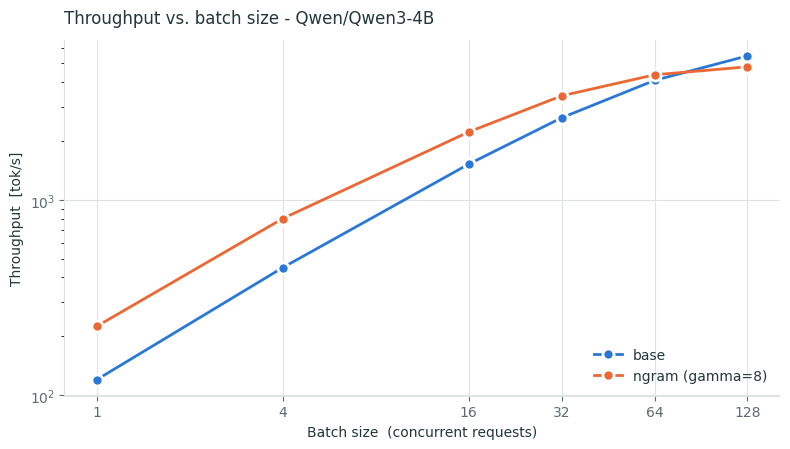

In [12]:
batches = [bs for bs, _ in SWEEP]

line_plot(
    batches,
    {
        "base": [base_results[k] for k in SWEEP],
        f"ngram (gamma={GAMMA})": [spec_results[k] for k in SWEEP],
    },
    title=f"Throughput vs. batch size - {VERIFIER}",
    xlabel="Batch size  (concurrent requests)",
    ylabel="Throughput  [tok/s]",
)
plt.show()

This plot illustrates where speculative decoding can fail: in the low batch size regime, the GPU is idle and 
the extra $\gamma$ verified tokens are free to calculate. At $B = 16$ the verifier is already processing $16(\gamma+1)$
tokens per step, which pushes it towards the roofline crossover. The drafted tokens stop being free
and the speedup shrinks, possibly below $1$. 

### What to take away

- Speculative decoding buys you **arithmetic intensity** in a regime where you have no batch to fill the
  GPU with. It is a fix for the memory-bound decode phase, not a general speedup.
- It is highly dependent $\alpha$, and $\alpha$ is a property of the *(drafter, verifier, task)*
  triple. Always measure it on your own workload before tuning $\gamma$.
- It is **lossless**: identical outputs, so it is safe to leave on for evaluation runs. Unlike
  quantization or pruning, it costs you no accuracy to defend in a paper.
- It stops helping under load. If your server already runs large batches, you are past the roofline
  crossover and the verifier's extra $\gamma$ tokens are no longer free.